In [2]:
from model_driver import driver
from iotools import read_results

In [3]:
# runs model
#outputfile = driver(create_ncf=True)
outputfile = r'/Users/jpnousu/SpaFHy-Peat_private/results/202511181802.nc'
# reads results from .nc-file
results = read_results(outputfile)

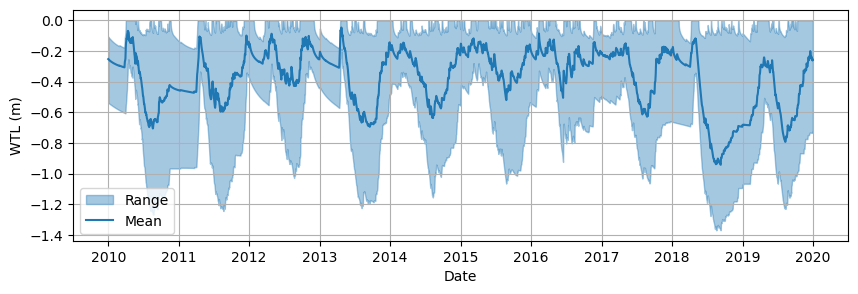

In [9]:
import matplotlib.pyplot as plt

da_min = results['soil_ground_water_level'].min(dim='j')[:,0]
da_max = results['soil_ground_water_level'].max(dim='j')[:,0]

# Extract the time coordinate (replace 'date' with your actual time dim name if different)
time = results['date'].values

# Plot
plt.figure(figsize=(10, 3))
plt.fill_between(time, da_min, da_max, color='tab:blue', alpha=0.4, label='Range')
plt.plot(time, results['soil_ground_water_level'].mean(dim='j'), color='tab:blue', label='Mean')
plt.xlabel("Date")
plt.ylabel("WTL (m)")
plt.legend()
plt.grid(True)
plt.savefig('figs/wtl.png', dpi=300, bbox_inches="tight")

In [4]:
import pandas as pd

sites_file_csv = r'/Users/jpnousu/Library/CloudStorage/OneDrive-SharedLibraries-Luonnonvarakeskus/PeatHIKET-PeatHydrology - Tiedostot/data/csv/sites_ensemble.csv'
sites_ensemble = pd.read_csv(sites_file_csv, sep=';')

In [17]:
# Select only
summer = results['soil_ground_water_level'].sel(
    date=results['soil_ground_water_level'].date.dt.month.isin([6, 7, 8])
)

# Then take the mean over the summer dates
mean_gw = summer.mean(dim='date')[0, :]
min_gw = summer.min(dim='date')[0, :]
max_gw = summer.max(dim='date')[0, :]

Text(0.12, 0.99, 'forcing_id = [0]\nditch_depth = [0.4, 1. ]\nditch_spacing = [ 40, 100]\ndecid_fraction = [0.2]\npine_fraction = [0.]\nspruce_fraction = [0.8]\nsoil_id = [1., 2.]')

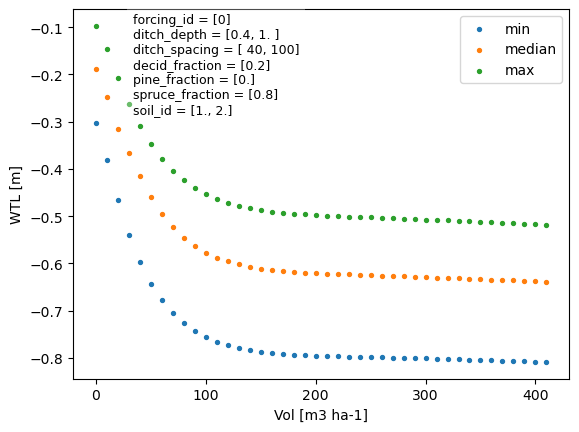

In [18]:
import numpy as np

params = {
    "forcing_id": np.array([0]), # 1 ruotsinkylä, 2 asmonkorpi
    "ditch_depth": np.array([0.4, 1.0]), 
    "ditch_spacing": np.array([40, 100]),
    "decid_fraction": np.array([0.2]),
    "pine_fraction": np.array([0.0]),
    "spruce_fraction": np.array([0.8]),
    "soil_id": np.array([1.0, 2.0]), # 1 sphagnum, 2 carex
}

vols = np.unique(sites_ensemble['vol'])
gwls = pd.DataFrame(index=vols, columns=['min', 'median', 'max'])

# For printing inside plot
param_text = "\n".join([
    f"{k} = {np.array2string(v, separator=', ')}"
    for k, v in params.items()
])

for vol in vols:
    mask = (sites_ensemble['vol'] == vol)

    for key, values in params.items():
        key_mask = np.zeros(len(sites_ensemble), dtype=bool)
        for v in values: # have to use another loop with np.isclose due to precision issue
            key_mask |= np.isclose(sites_ensemble[key], v)  # accumulate matches
        mask &= key_mask

    idx = sites_ensemble[mask].index

    gwls.loc[vol, 'median'] = mean_gw.loc[idx].median().values.mean()
    gwls.loc[vol, 'min'] = mean_gw.loc[idx].min().values.min()
    gwls.loc[vol, 'max'] = mean_gw.loc[idx].max().values.max()


# Plot
for col in gwls.columns:
    plt.scatter(gwls.index, gwls[col], s=8, label=f'{col}')

plt.legend()
plt.xlabel('Vol [m3 ha-1]')
plt.ylabel('WTL [m]')

plt.text(
    0.12, 0.99,
    param_text,
    ha='left', va='top',
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.3, edgecolor='none')
)

In [19]:
import xarray as xr
import os
import itertools
import numpy as np

# PARAMETERS
plot = False
params = {
    "forcing_id": np.array([0, 1]),
    "ditch_depth": np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]), #np.arange(0.4, 1.1, 0.1),
    "ditch_spacing": np.array([20., 40., 60.]), #np.arange(30., 110., 10.),
    "decid_fraction": np.array([0.2, 0.4]),
    "pine_fraction": np.array([0.0]),
    "spruce_fraction": np.array([0.6, 0.8]),
    "soil_id": np.array([1.0, 2.0]),
}

vols = np.unique(sites_ensemble['vol'])

# PREPARE XARRAY STRUCTURE
coords = params.copy()
coords["vol"] = vols

wtl_da = xr.DataArray(
    data=np.full([len(v) for v in coords.values()], np.nan),
    coords=coords,
    dims=list(coords.keys()),
    name="WTL",
)

# LOOP OVER PARAMETER COMBINATIONS
param_keys = list(params.keys())

for combo in itertools.product(*params.values()):
    combo_dict = dict(zip(param_keys, combo))
    if combo_dict["decid_fraction"] + combo_dict["pine_fraction"] + combo_dict["spruce_fraction"] > 1.0:
        continue

    # Build text for plotting annotation
    param_text = "\n".join([f"{k} = {v}" for k, v in combo_dict.items()])


    # Will store per-volume WTL for plotting
    gwls = []

    # ---- Loop over volumes
    for vol in vols:
        mask = (sites_ensemble['vol'] == vol)

        # Apply all filters
        for key, chosen_value in combo_dict.items():
            mask &= np.isclose(sites_ensemble[key], chosen_value)

        idx = sites_ensemble[mask].index

        if len(idx) == 0:
            wtl_val = np.nan
        else:
            wtl_val = mean_gw.loc[idx].median().values.mean()

        # Save in xarray structure
        wtl_da.loc[{**combo_dict, "vol": vol}] = wtl_val

       # Save for plotting
        gwls.append(wtl_val)

    if plot:
        # PLOT FOR THIS COMBO
        plt.figure()
        plt.scatter(vols, gwls, s=8)
        plt.xlabel("Vol [m3 ha-1]")
        plt.ylabel("WTL [m]")

        plt.text(
            0.02, 0.98,
            param_text,
            ha='left', va='top',
            transform=plt.gca().transAxes,
            fontsize=9,
            bbox=dict(facecolor='white', alpha=0.3, edgecolor='none')
        )
        plt.tight_layout()

# FINAL DATASET
ds = xr.Dataset({"WTL": wtl_da})

# Add units to coordinates
ds['vol'].attrs['units'] = 'm³ ha⁻¹'
ds['ditch_depth'].attrs['units'] = 'm'
ds['ditch_spacing'].attrs['units'] = 'm'
ds['WTL'].attrs['units'] = 'm'
ds['forcing_id'].attrs['description'] = '1 = ruotsinkyla, 2 = asmonkorpi'
ds['soil_id'].attrs['description'] = '1 = sphagnum, 2 = carex'

file = os.path.splitext(outputfile)[0] + '_wtl_vol_2.nc'
ds.to_netcdf(file)

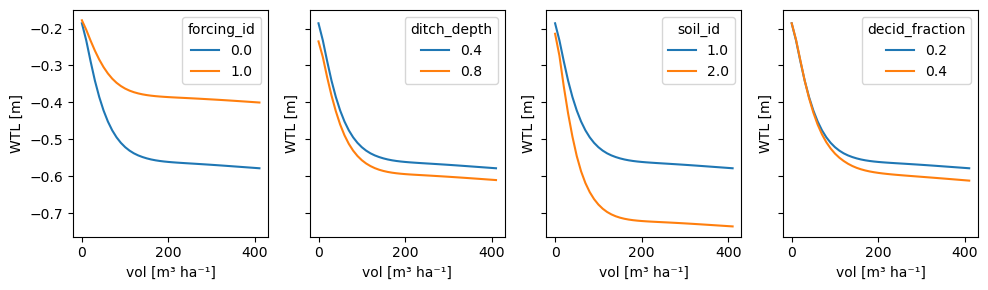

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(10, 3), sharey=True)

# --- 1. Forcing ID ---
ax = axes[0]
forcings = np.array([0.0, 1.0])
for forcing in forcings:
    ds.sel(forcing_id=forcing, 
           ditch_depth=0.4, 
           ditch_spacing=40., 
           decid_fraction=0.2, 
           pine_fraction=0.0, 
           spruce_fraction=0.8, 
           soil_id=1.0)['WTL'].plot(ax=ax, label=f'{forcing}')
ax.set_title("")
ax.legend(title="forcing_id")

# --- 2. Ditch depth ---
ax = axes[1]
ditch_depths = np.array([0.4, 0.8])
for ditch_depth in ditch_depths:
    ds.sel(forcing_id=0., 
           ditch_depth=ditch_depth, 
           ditch_spacing=40., 
           decid_fraction=0.2, 
           pine_fraction=0.0, 
           spruce_fraction=0.8, 
           soil_id=1.0)['WTL'].plot(ax=ax, label=f'{ditch_depth}')
ax.legend(title="ditch_depth")
ax.set_title("")

# --- 3. Soil ID ---
ax = axes[2]
soil_ids = np.array([1.0, 2.0])
for soil_id in soil_ids:
    ds.sel(forcing_id=0., 
           ditch_depth=0.4, 
           ditch_spacing=40., 
           decid_fraction=0.2, 
           pine_fraction=0.0, 
           spruce_fraction=0.8, 
           soil_id=soil_id)['WTL'].plot(ax=ax, label=f'{soil_id}')
ax.legend(title="soil_id")
ax.set_title("")

# --- 4. Fractions (decid + spruce) ---
ax = axes[3]
decid_fractions = np.array([0.2, 0.4])
spruce_fractions = np.array([0.8, 0.6])
for decid_fraction, spruce_fraction in zip(decid_fractions, spruce_fractions):
    ds.sel(forcing_id=0., 
           ditch_depth=0.4, 
           ditch_spacing=40., 
           decid_fraction=decid_fraction, 
           pine_fraction=0.0, 
           spruce_fraction=spruce_fraction, 
           soil_id=1.0)['WTL'].plot(ax=ax, 
                                     label=f'{decid_fraction}')
ax.legend(title='decid_fraction')
ax.set_title("")

plt.tight_layout()
plt.savefig('figs/wtl_vol_2.png', dpi=300, bbox_inches="tight")


In [9]:
from scipy.interpolate import interp1d

# Test interpolation function
# Probably best to save vol-gwl relationships in .txt file and share
#interp_fs = []
#interp_fs.append(interp1d(
#    gwls.index,                 # x-values: volume
#    gwls['median'],               # y-values: median WTL
#    kind='linear',              # linear interpolation (can also use 'cubic')
#    fill_value='interpolate'    # allow extrapolation outside known range
#))

TypeError: list indices must be integers or slices, not str